In [1]:
import torch
import numpy as np
from matplotlib import pyplot as plt

## 3.1 Автоматическое дифференцирование в `torch`

3.1.1 Воспользовавшись классами `Neuron` и `SquaredLoss` из задачи 2.4.1 и автоматическим дифференцированием, которое предоставляет `torch`, решить задачу регрессии. Для оптимизации использовать стохастический градиетный спуск.

In [10]:
from sklearn.datasets import make_regression

X, y, coef = make_regression(n_features=4, n_informative=4, coef=True, bias=0.5)
X = torch.from_numpy(X).to(dtype=torch.float32)
y = torch.from_numpy(y).to(dtype=torch.float32)

In [11]:
class Neuron:

    def __init__(self,n_inputs: int):
        self.weights = torch.randn(n_inputs, 1, requires_grad=True)
        self.bias = torch.randn(1, 1, requires_grad=True)
    def __call__(self, inputs: torch.Tensor):
        output = inputs @ self.weights + self.bias
        return output
    # def backward(self):
    #     self.dweights = self.weights.grad
    #     self.dbias = self.bias.grad

In [12]:
class SquaredLoss:
    def __call__(self,
                 y_pred: torch.Tensor,
                 y_true: torch.Tensor):
        return torch.mean((y_true - y_pred) ** 2)

In [13]:
X.shape[1]

4

In [14]:
neuron = Neuron(X.shape[1])
criterion = SquaredLoss()
lr = 0.01


for epoch in range(100):
    for x_example, y_example in zip(X, y):
        y_pred = neuron(x_example)
        loss = criterion(y_pred, y_example)
        loss.backward()
        with torch.no_grad():
            neuron.weights -= lr * neuron.weights.grad
            neuron.bias -= lr * neuron.bias.grad
        neuron.weights.grad.zero_()
        neuron.bias.grad.zero_()
    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss: {loss.item()}")

Epoch: 0 | Loss: 270.94891357421875
Epoch: 10 | Loss: 2.3283064365386963e-10
Epoch: 20 | Loss: 2.3283064365386963e-10
Epoch: 30 | Loss: 2.3283064365386963e-10
Epoch: 40 | Loss: 2.3283064365386963e-10
Epoch: 50 | Loss: 2.3283064365386963e-10
Epoch: 60 | Loss: 2.3283064365386963e-10
Epoch: 70 | Loss: 2.3283064365386963e-10
Epoch: 80 | Loss: 2.3283064365386963e-10
Epoch: 90 | Loss: 2.3283064365386963e-10


In [15]:
neuron.weights, coef

(tensor([[20.4436],
         [85.4021],
         [47.4548],
         [43.6050]], requires_grad=True),
 array([20.44355521, 85.40208984, 47.45474988, 43.60504077]))

3.1.2 Воспользовавшись классами `Linear` и `MSELoss` из задачи 2.1.4 и 2.3.1, `ReLU` из 2.2.1 и автоматическим дифференцированием, которое предоставляет `torch`, решить задачу регрессии. Для оптимизации использовать пакетный градиентный спуск. Вывести график функции потерь в зависимости от номера эпохи. Вывести на одном графике исходные данные и предсказанные значения.

In [16]:
X = torch.linspace(0, 1, 100).view(-1, 1)
y = torch.sin(2 * np.pi * X) + 0.5 * torch.rand(X.size())

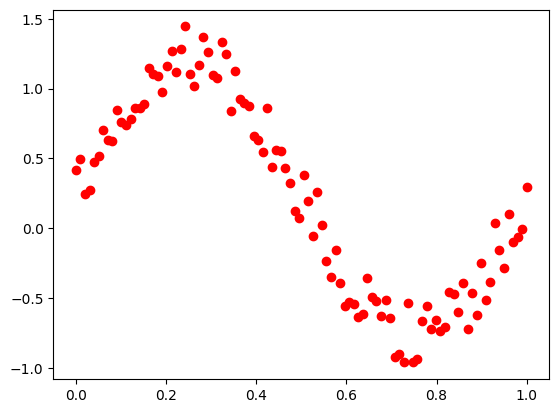

In [17]:
plt.scatter(X, y,color="r");

In [18]:
class Linear():
    def __init__(self,n_f,n_n):
        self.weights = torch.randn(n_f,n_n, requires_grad=True)
        self.bias = torch.randn(1, n_n, requires_grad=True)
    def __call__(self, inputs: torch.Tensor):
        output = inputs @ self.weights + self.bias
        return output
class MSELoss:
    def __call__(self,
                 y_pred: torch.Tensor,
                 y_true: torch.Tensor):
        return torch.mean((y_true - y_pred) ** 2)
class Relu:
    def __call__(self,x):
        x[x<0]=0
        return x

In [20]:
fc1 = Linear(1,20)
fc12=  Linear(20,10)
fc2=  Linear(10,1)
relu= Relu()

criterion = MSELoss()
lr = 0.01
los = []

for epoch in range(40000):
        y_pred1 = relu(fc12(relu(fc1(X))))
        y_pred  = fc2(y_pred1)

        loss = criterion(y_pred, y)
        loss.backward()
        with torch.no_grad():
            fc1.weights -= lr * fc1.weights.grad
            fc1.bias -= lr * fc1.bias.grad
            fc2.weights -= lr * fc2.weights.grad
            fc2.bias -= lr * fc2.bias.grad
            fc12.weights -= lr * fc12.weights.grad
            fc12.bias -= lr * fc12.bias.grad
        fc1.weights.grad.zero_()
        fc1.bias.grad.zero_()
        fc2.weights.grad.zero_()
        fc2.bias.grad.zero_()
        fc12.weights.grad.zero_()
        fc12.bias.grad.zero_()
        los.append(loss.item())
        if epoch % 1000 == 0:
            print(f"Epoch: {epoch} | Loss: {loss.item()}")

Epoch: 0 | Loss: 9.356002807617188
Epoch: 1000 | Loss: 0.019476814195513725
Epoch: 2000 | Loss: 0.018522052094340324
Epoch: 3000 | Loss: 0.018434632569551468
Epoch: 4000 | Loss: 0.01839536614716053
Epoch: 5000 | Loss: 0.01835084706544876
Epoch: 6000 | Loss: 0.01831543818116188
Epoch: 7000 | Loss: 0.018169419839978218
Epoch: 8000 | Loss: 0.01773599348962307
Epoch: 9000 | Loss: 0.01761535555124283
Epoch: 10000 | Loss: 0.017520807683467865
Epoch: 11000 | Loss: 0.01749206706881523
Epoch: 12000 | Loss: 0.017469529062509537
Epoch: 13000 | Loss: 0.01744796335697174
Epoch: 14000 | Loss: 0.017426999285817146
Epoch: 15000 | Loss: 0.01740642823278904
Epoch: 16000 | Loss: 0.017386354506015778
Epoch: 17000 | Loss: 0.01736728847026825
Epoch: 18000 | Loss: 0.01734858937561512
Epoch: 19000 | Loss: 0.017330193892121315
Epoch: 20000 | Loss: 0.01731203682720661
Epoch: 21000 | Loss: 0.017294060438871384
Epoch: 22000 | Loss: 0.017276322469115257
Epoch: 23000 | Loss: 0.017258750274777412
Epoch: 24000 | Loss

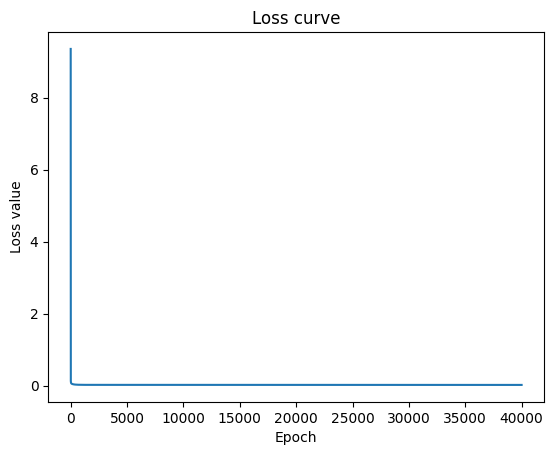

In [21]:
plt.plot(range(len(los)),los)
plt.title("Loss curve")
plt.xlabel("Epoch")
plt.ylabel("Loss value");

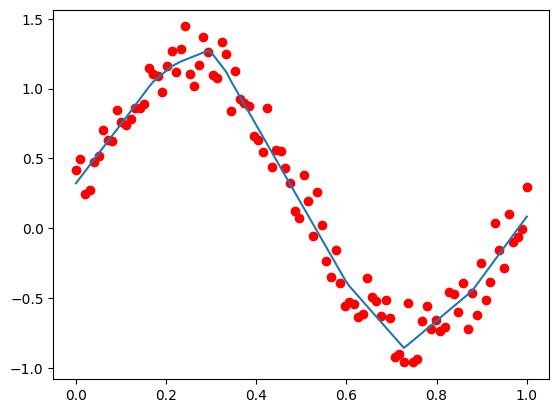

In [22]:
plt.plot(X.detach(),y_pred.detach())
plt.scatter(X, y,color="r");

## 3.2 Алгоритмы оптимизации в `torch.optim`

In [41]:
import torch.optim as optim
import torch.nn as nn

In [38]:
fc1 = nn.Linear(1,20)
fc12 = nn.Linear(20,10)
fc2 = nn.Linear(10,1)
relu = nn.Sigmoid()

model =  nn.Sequential(fc1,
         relu,
         fc12,
         relu,
         fc2)
optim= optim.SGD(model.parameters(),lr=0.05)
criterion = MSELoss()
los = []

for epoch in range(40000):
        y_pred1 = relu(fc12(relu(fc1(X))))
        y_pred  = fc2(y_pred1)

        loss = criterion(y_pred, y)
        loss.backward()
        optim.step()
        # with torch.no_grad():
        #     # fc1.weights -= lr * fc1.weights.grad
        #     # fc1.bias -= lr * fc1.bias.grad
        #     # fc2.weights -= lr * fc2.weights.grad
        #     # fc2.bias -= lr * fc2.bias.grad
        #     # fc12.weights -= lr * fc12.weights.grad
        #     # fc12.bias -= lr * fc12.bias.grad
        optim.zero_grad()
        # fc1.weights.grad.zero_()
        # fc1.bias.grad.zero_()
        # fc2.weights.grad.zero_()
        # fc2.bias.grad.zero_()
        # fc12.weights.grad.zero_()
        # fc12.bias.grad.zero_()

        los.append(loss.item())
        if epoch % 1000 == 0:
            print(f"Epoch: {epoch} | Loss: {loss.item()}")

Epoch: 0 | Loss: 0.5824909806251526
Epoch: 1000 | Loss: 0.2104620784521103
Epoch: 2000 | Loss: 0.2002154290676117
Epoch: 3000 | Loss: 0.1992732435464859
Epoch: 4000 | Loss: 0.19810208678245544
Epoch: 5000 | Loss: 0.19652225077152252
Epoch: 6000 | Loss: 0.19425338506698608
Epoch: 7000 | Loss: 0.19076450169086456
Epoch: 8000 | Loss: 0.18498943746089935
Epoch: 9000 | Loss: 0.1748885214328766
Epoch: 10000 | Loss: 0.1576576977968216
Epoch: 11000 | Loss: 0.13281255960464478
Epoch: 12000 | Loss: 0.10243120044469833
Epoch: 13000 | Loss: 0.06916215270757675
Epoch: 14000 | Loss: 0.04603260010480881
Epoch: 15000 | Loss: 0.036864809691905975
Epoch: 16000 | Loss: 0.033903688192367554
Epoch: 17000 | Loss: 0.03250007703900337
Epoch: 18000 | Loss: 0.03144756704568863
Epoch: 19000 | Loss: 0.03052464686334133
Epoch: 20000 | Loss: 0.02969115786254406
Epoch: 21000 | Loss: 0.028934532776474953
Epoch: 22000 | Loss: 0.028246326372027397
Epoch: 23000 | Loss: 0.027619171887636185
Epoch: 24000 | Loss: 0.0270466

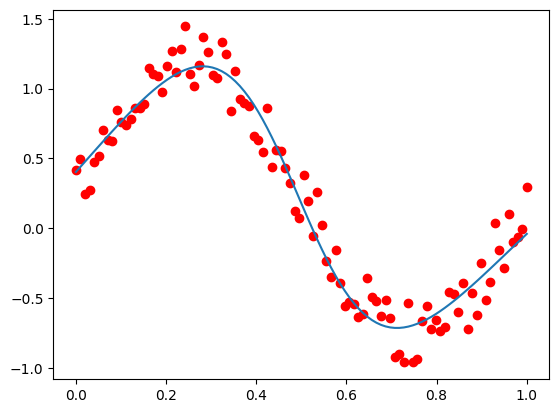

In [39]:
plt.plot(X.detach(),y_pred.detach())
plt.scatter(X, y,color="r");

3.2.1 Решить задачу 3.1.1, воспользовавшись оптимизатором `optim.SDG` для применения стохастического градиентого спуска

In [42]:
neuron = Neuron(X.shape[1])
criterion = SquaredLoss()
#lr = 0.01
optimizer = optim.SGD([neuron.weights, neuron.bias], lr = 0.01)

for epoch in range(100):
    for x_example, y_example in zip(X, y):
        y_pred = neuron(x_example)
        loss = criterion(y_pred, y_example)
        loss.backward()
        optimizer.step()
        # with torch.no_grad():
        #     neuron.weights -= lr * neuron.weights.grad
        #     neuron.bias -= lr * neuron.bias.grad
        optimizer.zero_grad()
        # neuron.weights.grad.zero_()
        # neuron.bias.grad.zero_()
    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss: {loss.item()}")

Epoch: 0 | Loss: 0.2762511670589447
Epoch: 10 | Loss: 0.6700004935264587
Epoch: 20 | Loss: 0.8210555911064148
Epoch: 30 | Loss: 0.8674099445343018
Epoch: 40 | Loss: 0.8809964656829834
Epoch: 50 | Loss: 0.8849298357963562
Epoch: 60 | Loss: 0.8860648274421692
Epoch: 70 | Loss: 0.8863909244537354
Epoch: 80 | Loss: 0.8864854574203491
Epoch: 90 | Loss: 0.8865130543708801


In [43]:
y

tensor([[ 0.4170],
        [ 0.4988],
        [ 0.2451],
        [ 0.2741],
        [ 0.4760],
        [ 0.5144],
        [ 0.7039],
        [ 0.6330],
        [ 0.6247],
        [ 0.8442],
        [ 0.7640],
        [ 0.7374],
        [ 0.7815],
        [ 0.8636],
        [ 0.8599],
        [ 0.8892],
        [ 1.1482],
        [ 1.1038],
        [ 1.0896],
        [ 0.9733],
        [ 1.1621],
        [ 1.2681],
        [ 1.1167],
        [ 1.2862],
        [ 1.4448],
        [ 1.1046],
        [ 1.0209],
        [ 1.1698],
        [ 1.3672],
        [ 1.2628],
        [ 1.0976],
        [ 1.0796],
        [ 1.3320],
        [ 1.2493],
        [ 0.8395],
        [ 1.1231],
        [ 0.9228],
        [ 0.8955],
        [ 0.8762],
        [ 0.6574],
        [ 0.6307],
        [ 0.5494],
        [ 0.8648],
        [ 0.4365],
        [ 0.5581],
        [ 0.5550],
        [ 0.4308],
        [ 0.3249],
        [ 0.1246],
        [ 0.0711],
        [ 0.3788],
        [ 0.1965],
        [-0.

In [45]:
neuron(X)

tensor([[ 1.0562],
        [ 1.0394],
        [ 1.0226],
        [ 1.0058],
        [ 0.9890],
        [ 0.9722],
        [ 0.9554],
        [ 0.9385],
        [ 0.9217],
        [ 0.9049],
        [ 0.8881],
        [ 0.8713],
        [ 0.8545],
        [ 0.8377],
        [ 0.8209],
        [ 0.8041],
        [ 0.7873],
        [ 0.7705],
        [ 0.7537],
        [ 0.7369],
        [ 0.7201],
        [ 0.7032],
        [ 0.6864],
        [ 0.6696],
        [ 0.6528],
        [ 0.6360],
        [ 0.6192],
        [ 0.6024],
        [ 0.5856],
        [ 0.5688],
        [ 0.5520],
        [ 0.5352],
        [ 0.5184],
        [ 0.5016],
        [ 0.4848],
        [ 0.4679],
        [ 0.4511],
        [ 0.4343],
        [ 0.4175],
        [ 0.4007],
        [ 0.3839],
        [ 0.3671],
        [ 0.3503],
        [ 0.3335],
        [ 0.3167],
        [ 0.2999],
        [ 0.2831],
        [ 0.2663],
        [ 0.2494],
        [ 0.2326],
        [ 0.2158],
        [ 0.1990],
        [ 0.

3.2.2 Решить задачу 3.1.2, воспользовавшись оптимизатором `optim.Adam` для применения пакетного градиентого спуска. Вывести график функции потерь в зависимости от номера эпохи. Вывести на одном графике исходные данные и предсказанные значения.

In [46]:
X = torch.linspace(0, 1, 100).view(-1, 1)
y = torch.sin(2 * np.pi * X) + 0.5 * torch.rand(X.size())

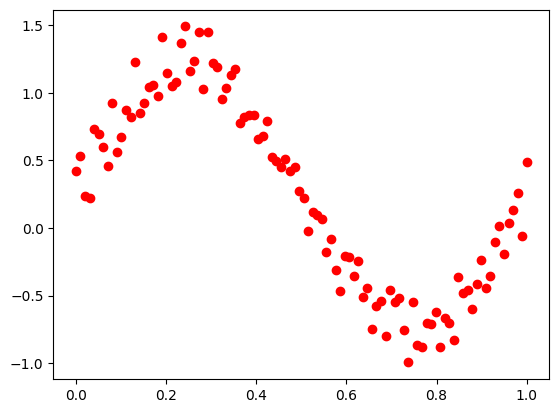

In [47]:
plt.scatter(X, y, color="r");

In [48]:
class Linear():
    def __init__(self,n_f,n_n):
        self.weights = torch.randn(n_f, n_n, requires_grad=True)
        self.bias = torch.randn(1, n_n, requires_grad=True)
    def __call__(self, inputs: torch.Tensor):
        output = inputs @ self.weights + self.bias
        return output
class MSELoss:
    def __call__(self,
                 y_pred: torch.Tensor,
                 y_true: torch.Tensor):
        return torch.mean((y_true - y_pred) ** 2)
class Relu:
    def __call__(self,x):
        x[x<0]=0
        return x

In [49]:
fc1 = Linear(1,30)
fc12 = Linear(30,20)
fc2 = Linear(20,1)
relu = Relu()

criterion = MSELoss()
batch_size = 20
los = []
optimizer = optim.Adam([fc1.weights, fc1.bias, fc2.weights, fc2.bias, fc12.weights, fc12.bias], lr = 0.01)

for epoch in range(10000):
  loss_for_epoch = 0
  for X_batch, y_batch in zip(X.split(batch_size), y.split(batch_size)):
    y_pred1 = relu(fc12(relu(fc1(X_batch))))
    y_pred  = fc2(y_pred1)

    loss = criterion(y_pred, y_batch)
    loss.backward()
    optimizer.step()
    # with torch.no_grad():
    #     fc1.weights -= lr * fc1.weights.grad
    #     fc1.bias -= lr * fc1.bias.grad
    #     fc2.weights -= lr * fc2.weights.grad
    #     fc2.bias -= lr * fc2.bias.grad
    #     fc12.weights -= lr * fc12.weights.grad
    #     fc12.bias -= lr * fc12.bias.grad
    optimizer.zero_grad()
    # fc1.weights.grad.zero_()
    # fc1.bias.grad.zero_()
    # fc2.weights.grad.zero_()
    # fc2.bias.grad.zero_()
    # fc12.weights.grad.zero_()
    # fc12.bias.grad.zero_()
    #los.append(loss.item())
    loss_for_epoch += loss.item()
  loss_for_epoch /= len(X.split(batch_size))
  los.append(loss_for_epoch)
  if epoch % 1000 == 0:
      print(f"Epoch: {epoch} | Loss for epoch: {loss_for_epoch}")

Epoch: 0 | Loss for epoch: 20.087315982580186
Epoch: 1000 | Loss for epoch: 0.020188555866479874
Epoch: 2000 | Loss for epoch: 0.020280574262142182
Epoch: 3000 | Loss for epoch: 0.020220830477774142
Epoch: 4000 | Loss for epoch: 0.026121898368000985
Epoch: 5000 | Loss for epoch: 0.020643866807222366
Epoch: 6000 | Loss for epoch: 0.02710182387381792
Epoch: 7000 | Loss for epoch: 0.01841849200427532
Epoch: 8000 | Loss for epoch: 0.01844111457467079
Epoch: 9000 | Loss for epoch: 0.018653012439608575


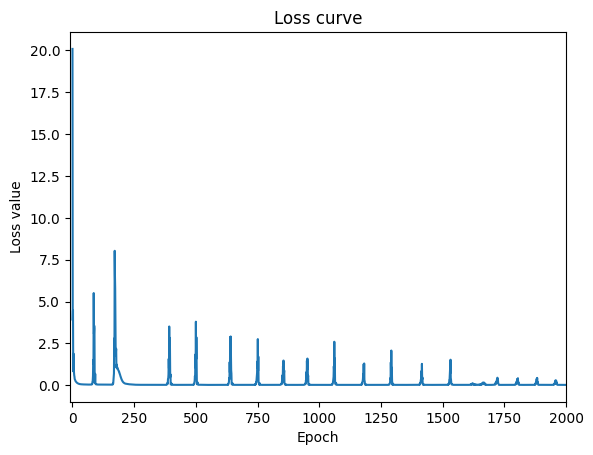

In [50]:
plt.plot(range(len(los)), los)
plt.title("Loss curve")
plt.xlabel("Epoch")
plt.ylabel("Loss value");
plt.xlim(-10, 2000);

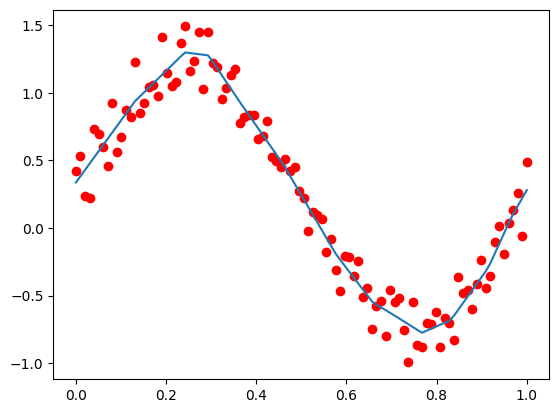

In [51]:
plt.scatter(X, y, color="r");
y_pred = fc2(relu(fc12(relu(fc1(X)))))
plt.plot(X.detach(), y_pred.detach());

## 3.3 Построение сетей при помощи `torch.nn`

In [59]:
import torch.nn as nn

3.3.1 Решить задачу регрессии, соблюдая следующие условия:

1. Оформить нейронную сеть в виде класса - наследника `nn.Module`
2. При создании сети использовать готовые блоки из `torch.nn`: слои, функции активации, функции потерь и т.д.
3. Для оптимизации использовать любой алгоритм оптимизации из `torch.optim`

In [60]:
class mymodel(nn.Module):
    def __init__(self,n_f):
        super(mymodel,self).__init__()
        self.fc1= nn.Linear(n_f,20)
        self.fc12= nn.Linear(20,30)
        self.fc2= nn.Linear(30,1)
        self.relu = nn.ReLU()
    def __call__(self,x):
        return self.fc2(self.relu(self.fc12(self.relu(self.fc1(x)))))

In [61]:
X = torch.linspace(0, 1, 100).view(-1, 1)
y = torch.sin(2 * np.pi * X) + 0.1 * torch.rand(X.size())

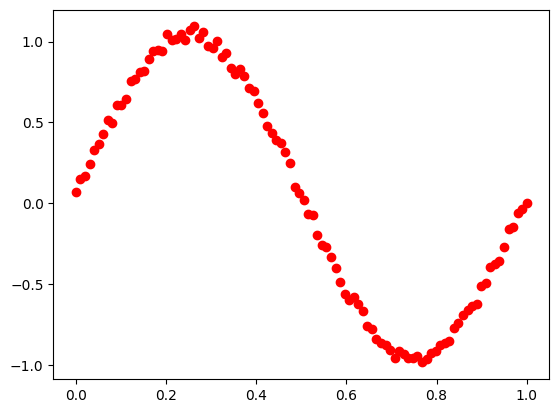

In [63]:
plt.scatter(X, y, c = 'r')

In [64]:
import torch.optim as optim

In [65]:
my= mymodel(1)

opt= optim.Adam(my.parameters(),lr=0.01)
criterion = nn.MSELoss()
los = []

for epoch in range(20000):
        y_pred = my(X)
        loss = criterion(y_pred, y)
        loss.backward()
        opt.step()
        opt.zero_grad()
        los.append(loss.item())
        if epoch % 1000 == 0:
            print(f"Epoch: {epoch} | Loss: {loss.item()}")

Epoch: 0 | Loss: 0.5005236268043518
Epoch: 1000 | Loss: 0.0007592309848405421
Epoch: 2000 | Loss: 0.0006898964056745172
Epoch: 3000 | Loss: 0.0006704820552840829
Epoch: 4000 | Loss: 0.0006721949321217835
Epoch: 5000 | Loss: 0.0007465581875294447
Epoch: 6000 | Loss: 0.0006406043539755046
Epoch: 7000 | Loss: 0.0007816252182237804
Epoch: 8000 | Loss: 0.0006469814688898623
Epoch: 9000 | Loss: 0.0006364430300891399
Epoch: 10000 | Loss: 0.0006943762418814003
Epoch: 11000 | Loss: 0.0006497502326965332
Epoch: 12000 | Loss: 0.0006151717389002442
Epoch: 13000 | Loss: 0.0007275675889104605
Epoch: 14000 | Loss: 0.000587984686717391
Epoch: 15000 | Loss: 0.0005732469144277275
Epoch: 16000 | Loss: 0.0007724432507529855
Epoch: 17000 | Loss: 0.0005816880729980767
Epoch: 18000 | Loss: 0.0005778036429546773
Epoch: 19000 | Loss: 0.0005469205207191408


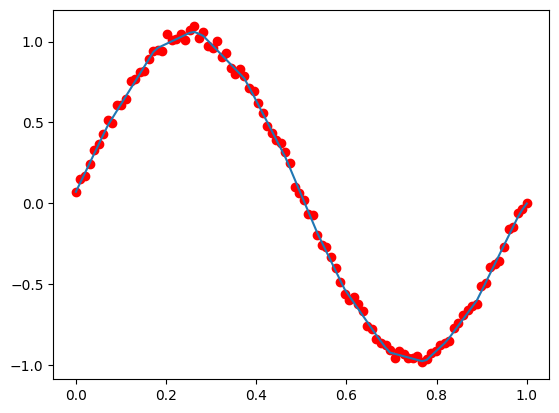

In [66]:
plt.plot(X.detach(),y_pred.detach())
plt.scatter(X, y,color="r");

3.3.2 Решить задачу регрессии, соблюдая следующие условия:

1. Оформить нейронную сеть в виде объекта `nn.Sequential`
2. При создании сети использовать готовые блоки из `torch.nn`: слои, функции активации, функции потерь и т.д.
3. Для оптимизации использовать любой алгоритм оптимизации из `torch.optim`

In [67]:
my = nn.Sequential(
                nn.Linear(X.shape[1], 20),
                nn.ReLU(),
                nn.Linear(20, 30),
                nn.ReLU(),
                nn.Linear(30, 1))

opt = optim.Adam(my.parameters(), lr=0.01)
criterion = nn.MSELoss()
los = []

for epoch in range(20000):
        y_pred = my(X)
        loss = criterion(y_pred, y)
        loss.backward()
        opt.step()
        opt.zero_grad()
        los.append(loss.item())
        if epoch % 1000 == 0:
            print(f"Epoch: {epoch} | Loss: {loss.item()}")

Epoch: 0 | Loss: 0.5244453549385071
Epoch: 1000 | Loss: 0.0008731590351089835
Epoch: 2000 | Loss: 0.0006857233238406479
Epoch: 3000 | Loss: 0.0007455721497535706
Epoch: 4000 | Loss: 0.0006115788128226995
Epoch: 5000 | Loss: 0.0006202094373293221
Epoch: 6000 | Loss: 0.0006752199842594564
Epoch: 7000 | Loss: 0.0006283995462581515
Epoch: 8000 | Loss: 0.0006327786250039935
Epoch: 9000 | Loss: 0.0006833989755250514
Epoch: 10000 | Loss: 0.0006202129879966378
Epoch: 11000 | Loss: 0.0005500921397469938
Epoch: 12000 | Loss: 0.0005628253566101193
Epoch: 13000 | Loss: 0.0005009348969906569
Epoch: 14000 | Loss: 0.0005732715362682939
Epoch: 15000 | Loss: 0.0009894364047795534
Epoch: 16000 | Loss: 0.0005370111903175712
Epoch: 17000 | Loss: 0.0005046348087489605
Epoch: 18000 | Loss: 0.0007566172862425447
Epoch: 19000 | Loss: 0.000512266589794308


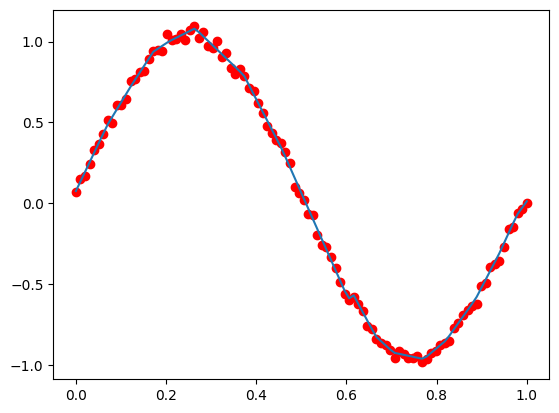

In [68]:
plt.plot(X.detach(), y_pred.detach())
plt.scatter(X, y, color = 'r')

## 3.4. Datasets and dataloaders

В библиотеке PyTorch DataLoader является важным компонентом для управления загрузкой данных, который упрощает итерацию по данным во время тренировки нейронных сетей. DataLoader используется для создания сложных и гибких конвейеров загрузки данных, что особенно полезно при работе с большими наборами данных или при выполнении операций, требующих предварительной обработки данных.

### Основные функции DataLoader в PyTorch
#### Батчинг: Автоматически собирает отдельные элементы данных в батчи или пакеты. Это упрощает обработку нескольких образцов одновременно в модели.
#### Перемешивание: Перемешивает данные перед каждой эпохой обучения, что помогает предотвратить переобучение и гарантирует, что модель не учится определённому порядку представления данных.
#### Параллельная загрузка: Поддерживает загрузку данных в нескольких потоках с использованием num_workers, что значительно ускоряет предварительную обработку и подачу данных в модель, особенно на многопроцессорных системах.
#### Автоматическая обработка последнего батча: DataLoader автоматически обрабатывает последний батч, который может быть меньше, если размер набора данных не делится на размер батча.
#### Интеграция с Dataset: DataLoader тесно интегрирован с абстракцией Dataset, которая предоставляет интерфейс для доступа к данным. Dataset определяет, как загружать и форматировать данные, а DataLoader эффективно подаёт эти данные в модель.

In [69]:
from torch.utils.data import Dataset, DataLoader, TensorDataset

In [70]:
X = torch.linspace(0, 1, 100).view(-1, 1)
y = torch.sin(2 * np.pi * X) + 0.1 * torch.rand(X.size())

dataset = TensorDataset(X, y)
dataloader= DataLoader(dataset,20,shuffle=True)

In [71]:
my = nn.Sequential(
                nn.Linear(X.shape[1], 20),
                nn.ReLU(),
                nn.Linear(20, 30),
                nn.ReLU(),
                nn.Linear(30, 1))
opt= optim.SGD(my.parameters(),lr=0.01)
criterion = nn.MSELoss()
los = []

for epoch in range(1000):
        for i, (x, y_) in enumerate(dataloader):
            y_pred = my(x)
            loss = criterion(y_pred, y_)
            loss.backward()
            opt.step()
            opt.zero_grad()
            los.append(loss.item())
            print(f"epoch {epoch}--Batch {i}: Loss: {loss.item()}")
            # if epoch % 1000 == 0:
            #     print(f"Epoch: {epoch} | Loss: {loss.item()}")

epoch 0--Batch 0: Loss: 0.5749284625053406
epoch 0--Batch 1: Loss: 0.47296732664108276
epoch 0--Batch 2: Loss: 0.5170345902442932
epoch 0--Batch 3: Loss: 0.5611985325813293
epoch 0--Batch 4: Loss: 0.4384787678718567
epoch 1--Batch 0: Loss: 0.5991451144218445
epoch 1--Batch 1: Loss: 0.5320898294448853
epoch 1--Batch 2: Loss: 0.5301178097724915
epoch 1--Batch 3: Loss: 0.4708787798881531
epoch 1--Batch 4: Loss: 0.3689733147621155
epoch 2--Batch 0: Loss: 0.5184482932090759
epoch 2--Batch 1: Loss: 0.48474130034446716
epoch 2--Batch 2: Loss: 0.570682168006897
epoch 2--Batch 3: Loss: 0.4132119119167328
epoch 2--Batch 4: Loss: 0.471979558467865
epoch 3--Batch 0: Loss: 0.6757320165634155
epoch 3--Batch 1: Loss: 0.41680893301963806
epoch 3--Batch 2: Loss: 0.49193859100341797
epoch 3--Batch 3: Loss: 0.4113844335079193
epoch 3--Batch 4: Loss: 0.4161783754825592
epoch 4--Batch 0: Loss: 0.4549836218357086
epoch 4--Batch 1: Loss: 0.49451136589050293
epoch 4--Batch 2: Loss: 0.48032599687576294
epoch 4

3.4.1 Создать датасет, поставляющий данные из задачи 3.1.2.

Создать `DataLoader` на основе этого датасета и проверить работоспособность.

Воспользовавшись результатами 3.3.1 (или 3.3.2) обучите модель, пользуясь мини-пакетным градиентным спуском с размером пакета (`batch_size`) = 10

In [72]:
from torch.utils.data import Dataset, DataLoader, TensorDataset, random_split

In [73]:
X = torch.linspace(0, 1, 100).view(-1, 1)
y = torch.sin(2 * np.pi * X) + 0.5 * torch.rand(X.size())

In [74]:
class SinDataset(Dataset):
  def __init__(self, X, y):
    self.X = X
    self.y = y

  def __len__(self):
    return len(self.y)

  def __getitem__(self, idx):
    return self.X[idx], self.y[idx]

In [75]:
dataset = SinDataset(X, y)
dataloader = DataLoader(dataset, 10, shuffle = True)

In [76]:
my = nn.Sequential(
  nn.Linear(X.shape[1], 20),
  nn.ReLU(),
  nn.Linear(20, 30),
  nn.ReLU(),
  nn.Linear(30, 1)
)

optimizer = optim.Adam(my.parameters(), lr = 0.01)
criterion = nn.MSELoss()
los = []

for epoch in range(5000):
  loss_for_epoch = 0
  for X_batch, y_batch in dataloader:
    y_pred = my(X_batch)
    loss = criterion(y_pred, y_batch)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    loss_for_epoch += loss.item()
  loss_for_epoch /= len(dataloader)
  los.append(loss_for_epoch)
  if epoch % 1000 == 0:
      print(f"Epoch: {epoch} | Loss for epoch: {loss_for_epoch}")

Epoch: 0 | Loss for epoch: 0.5679415225982666
Epoch: 1000 | Loss for epoch: 0.015615362673997879
Epoch: 2000 | Loss for epoch: 0.015104874968528748
Epoch: 3000 | Loss for epoch: 0.01445161453448236
Epoch: 4000 | Loss for epoch: 0.01571713462471962


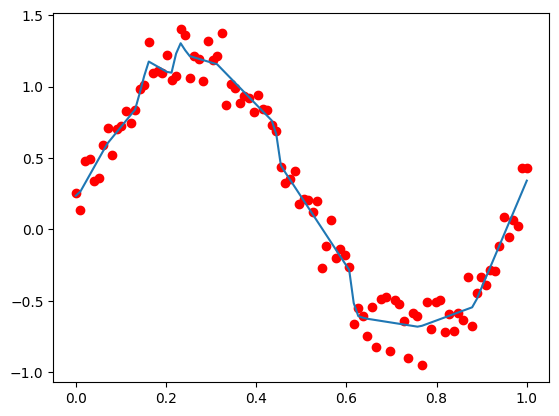

In [77]:
y_pred_full = my(X)
plt.plot(X.detach(), y_pred_full.detach())
plt.scatter(X, y, color = 'r')

#### 3.4.2 Предсказание цен алмазов

3.4.2.1 Создайте датасет на основе файла diamonds.csv.

1. Удалите все нечисловые столбцы
2. Целевой столбец (`y`) - `price`
3. Преобразуйте данные в тензоры корректных размеров

3.4.2.2 Разбейте датасет на обучающий и тестовый датасет при помощи `torch.utils.data.random_split`.

3.4.2.3 Обучите модель для предсказания цен при помощи мини-пакетного градиентного спуска (`batch_size = 256`).

3.4.2.4 Выведите график функции потерь в зависимости от номера эпохи (значение потерь для эпохи рассчитывайте как среднее значение ошибок на каждом батче). Проверьте качество модели на тестовой выборке.


In [78]:
import pandas as pd

In [79]:
df = pd.read_csv('diamonds.csv')
df.head()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [82]:
df.shape

(53940, 11)

In [83]:
df = df.drop('Unnamed: 0', axis = 1)
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [84]:
class DiamondsDataset(Dataset):
  def __init__(self, data):
    for col in data.columns:
      if data[col].dtype not in ('float64', 'int64'):
        data = data.drop(col, axis = 1)
    self.X = torch.tensor(data.drop('price', axis = 1).values, dtype = torch.float)
    self.y = torch.tensor(data['price'].values, dtype = torch.float)

  def __len__(self):
    return len(self.y)

  def __getitem__(self, idx):
    return self.X[idx], self.y[idx]

In [85]:
dataset = DiamondsDataset(df)
train_size = int(0.8 * len(dataset))  # 80% для обучения
test_size = len(dataset) - train_size  # 20% для тестирования
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])
print(len(train_dataset))
dataloader = DataLoader(train_dataset, 256, shuffle = True)
print(len(dataloader))

43152
169


In [86]:
my = nn.Sequential(
  nn.Linear(dataloader.dataset.dataset.X.shape[1], 20),
  nn.ReLU(),
  nn.Linear(20, 30),
  nn.ReLU(),
  nn.Linear(30, 1)
)

optimizer = optim.Adam(my.parameters(), lr = 0.01)
criterion = nn.MSELoss()
los = []

for epoch in range(100):
  loss_for_epoch = 0
  for X_batch, y_batch in dataloader:
    y_pred = my(X_batch)
    loss = criterion(y_pred.reshape(y_pred.shape[0]), y_batch)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    loss_for_epoch += loss.item()
  loss_for_epoch /= len(dataloader)
  los.append(loss_for_epoch)
  if epoch % 1 == 0:
      print(f"Epoch: {epoch} | Loss for epoch: {loss_for_epoch}")

Epoch: 0 | Loss for epoch: 17826488.431952663
Epoch: 1 | Loss for epoch: 11089066.24556213
Epoch: 2 | Loss for epoch: 2723856.355769231
Epoch: 3 | Loss for epoch: 2306793.351331361
Epoch: 4 | Loss for epoch: 2289210.1102071004
Epoch: 5 | Loss for epoch: 2265148.674556213
Epoch: 6 | Loss for epoch: 2247014.722633136
Epoch: 7 | Loss for epoch: 2231339.430473373
Epoch: 8 | Loss for epoch: 2216274.947485207
Epoch: 9 | Loss for epoch: 2202456.9378698226
Epoch: 10 | Loss for epoch: 2175893.924556213
Epoch: 11 | Loss for epoch: 2160668.1605029586
Epoch: 12 | Loss for epoch: 2159088.12056213
Epoch: 13 | Loss for epoch: 2155946.5081360945
Epoch: 14 | Loss for epoch: 2136559.2710798816
Epoch: 15 | Loss for epoch: 2117295.974852071
Epoch: 16 | Loss for epoch: 2112346.277366864
Epoch: 17 | Loss for epoch: 2105368.780325444
Epoch: 18 | Loss for epoch: 2094712.5207100592
Epoch: 19 | Loss for epoch: 2091761.322485207
Epoch: 20 | Loss for epoch: 2079434.4171597634
Epoch: 21 | Loss for epoch: 2083241.0

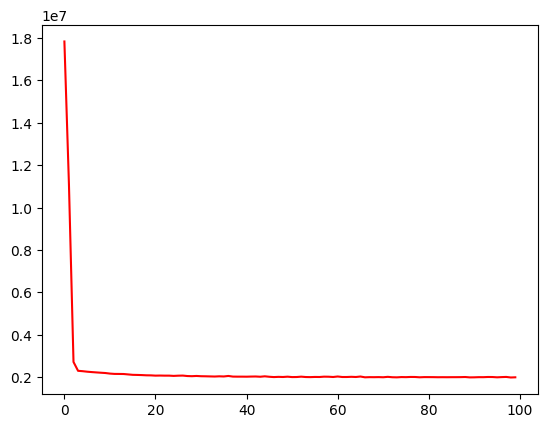

In [87]:
plt.plot(range(len(los)), los, c = 'r')

In [88]:
y_pred = my(test_dataset.dataset.X)
y_true = test_dataset.dataset.y
criterion(y_pred.reshape(-1), y_true)

tensor(2044469.7500, grad_fn=<MseLossBackward0>)

In [89]:
y_true

tensor([ 326.,  326.,  327.,  ..., 2757., 2757., 2757.])

In [90]:
y_pred.reshape(-1)


tensor([ 486.0186,  508.7447,  533.4305,  ..., 2063.8196, 3657.4653,
        2870.7334], grad_fn=<ViewBackward0>)

#### 3.4.3 Модифицируйте метод `__init__` датасета из 3.4.2 таким образом, чтобы он мог принимать параметр `transform: callable`. Реализуйте класс `DropColsTransform` для удаления нечисловых данных из массива. Реализуйте класс `ToTensorTransorm` для трансформации массива в тензор.

In [91]:
class DiamondsDataset(Dataset):
  def __init__(self, data, transform):
    self.transform = transform
    self.X = data.drop('price', axis = 1).values
    self.y = data['price'].values

  def __len__(self):
    return len(self.y)

  def __getitem__(self, idx):
    sample = (self.X[idx], self.y[idx])
    if self.transform:
      sample = self.transform(sample)
    return sample

In [92]:
class DropColsTransform:
  def __init__(self, drop):
    self.drop = drop

  def __call__(self, sample):
    X, y = sample
    # <удаление из X столбцов self.drop>
    X = np.delete(X, self.drop)
    return X.astype(float), y

In [93]:
class ToTensorTransform:
  def __call__(self, sample):
    X, y = sample
    # <преобразование X и y в тензоры>
    X = torch.from_numpy(X).type(torch.float)
    y = torch.tensor(y, dtype = torch.float)
    return X, y

In [94]:
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [95]:
from torchvision import transforms

drop = DropColsTransform(drop=[1, 2, 3])
to_tensor = ToTensorTransform()
dataset = DiamondsDataset(df, transforms.Compose([drop, to_tensor]))
dataloader = DataLoader(dataset, 256, shuffle = True)
dataloader.dataset.X

array([[0.23, 'Ideal', 'E', ..., 3.95, 3.98, 2.43],
       [0.21, 'Premium', 'E', ..., 3.89, 3.84, 2.31],
       [0.23, 'Good', 'E', ..., 4.05, 4.07, 2.31],
       ...,
       [0.7, 'Very Good', 'D', ..., 5.66, 5.68, 3.56],
       [0.86, 'Premium', 'H', ..., 6.15, 6.12, 3.74],
       [0.75, 'Ideal', 'D', ..., 5.83, 5.87, 3.64]], dtype=object)

In [96]:
for X_batch, y_batch in dataloader:
  print(X_batch.shape, y_batch.shape)
  break

torch.Size([256, 6]) torch.Size([256])
